#### Bajo estas líneas comenzaré a desgranar algunos csv para intentar contrastar la primera hipótesis, que planteaba que a partir de la aparición de _The Matrix_ en las salas de cine, el género de la ciencia ficción vio aumentado sus presupuestos de manera general y también la cantidad de personas que participaban en los procesos de efectos especiales.

# 🎬 Hipótesis 1 — Parte 1: Evolución de presupuestos en la Ciencia Ficción

### Empiezo cargando librerías y archivos

In [24]:
# importo librerías necesarias

import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import numpy as np


ruta_hipotesis1 = "../datos/brutos/hipotesis_1/tmdb_5000_movies.csv" # ruta al dataset

df_5000movies = pd.read_csv(ruta_hipotesis1) # cargo el csv
print(f"Dataset cargado con {df_5000movies.shape[0]} películas y {df_5000movies.shape[1]} columnas") # imprimo mensaje

Dataset cargado con 4803 películas y 20 columnas


In [25]:
df_5000movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

### Ahora buscaré qué columnas que contienen valores NuN y veré qué puedo hacer con ellas

In [26]:
nulos = df_5000movies.isnull().sum() # sumo los valores NuN de cada columna
nulos[nulos>0] # muestro los que son mayores a 0

homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

### La **columna homepage** es la página web de cada película y es irrelevante para el estudio, así que será **eliminada**. De la misma manera, **tagline** hace referencia a una frase que representa a la película, a menudo utilizada en los pósters, y también puede ser **eliminada**. La columna **overview** ofrece el resumen de la película, se puede **eliminar**, **runtime** es el tiempo que dura, esta **la puedo conservar** por si me sirve para algún tipo de análisis posterior. Por último, **release_date sí es totalmente relevante**, ya que es la fecha de lanzamiento de la película en cines.

In [27]:
df_5000movies.head(1) # miro la pinta de un registro para entenderlo mejor

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


### Y antes de empezar a limpiar valores NuN, también quiero mirar el resto de columnas, para conocer qué datos me valen y de cuáles puedo prescindir:

* **budget**: me vale
* **genres**: me vale
* **homepage**: fuera
* **id**: me vale
* **keywords**: fuera
* **original_language**: fuera
* **original_title**: fuera
* **overview**: fuera
* **popularity**: fuera
* **production_companies**: me vale
* **production_countries**: fuera
* **release_date**: me vale
* **revenue**: me vale
* **runtime**: fuera
* **spoken_languages**: fuera
* **status**: fuera
* **tagline**: fuera
* **title**: me vale
* **vote_average**: fuera
* **vote_count**: fuera

### Limpio el dataframe df_5000movies y me quedo solamente con las columnas que me valen.

In [28]:
# creo una lista con las columnas a eliminar

columnas_fuera = ["homepage", "keywords", "original_language", "original_title", "overview", "popularity", "production_countries", "production_companies", "runtime", "spoken_languages", "status", "tagline", "vote_average", "vote_count"]

df_5000movies_limpio = df_5000movies.drop(columns=columnas_fuera) # elimino las columnas

df_5000movies_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   budget        4803 non-null   int64
 1   genres        4803 non-null   str  
 2   id            4803 non-null   int64
 3   release_date  4802 non-null   str  
 4   revenue       4803 non-null   int64
 5   title         4803 non-null   str  
dtypes: int64(3), str(3)
memory usage: 225.3 KB


### Ahora tengo que ver cuál es la película que tiene un NaN en release_date, por si puedo encontrarlo en internet o, simplemente, elimino el registro y punto

In [29]:
peliculaNaN = df_5000movies_limpio["release_date"].isna() # obtengo la máscara para encontrar el registro NaN

df_5000movies_limpio[peliculaNaN] # busco el registro


,budget,genres,id,release_date,revenue,title
4553,0,[],380097,NaN,0,America Is Still the Place


### Viendo que la película no tiene presupuesto, géneros o ingresos, lo más sencillo es no complicarse y eliminarla del dataframe limpio

In [30]:
df_5000movies_limpio = df_5000movies_limpio.dropna(subset=["release_date"]) # elimino la fila de la columna release_Date con NaN
df_5000movies_limpio.info()

<class 'pandas.DataFrame'>
Index: 4802 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   budget        4802 non-null   int64
 1   genres        4802 non-null   str  
 2   id            4802 non-null   int64
 3   release_date  4802 non-null   str  
 4   revenue       4802 non-null   int64
 5   title         4802 non-null   str  
dtypes: int64(3), str(3)
memory usage: 262.6 KB


### Ahora vemos que tenemos 4802 registros, uno menos que antes, pero ya tenemos las columnas que queremos y sin nulos. Ahora, eso sí, tengo otro problema: la columna de género dice que contiene un string, pero es un texto que hay que convertir a un diccionario para obtener los valores que necesito

In [31]:
df_5000movies_limpio["genres"].head(5)

0    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1    [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
Name: genres, dtype: str

### Crearé una función sencilla para poder convertir los valores de la columna genre en una lista con los géneros de cada película del dataframe

In [32]:
def extraer_generos(texto): # inicio la función
    lista = ast.literal_eval(texto) # convierto el string en diccionario
    return [genero["name"] for genero in lista] # recorro el diccionario y me quedo solo con el campo name

In [33]:
df_5000movies_limpio["genres"] = df_5000movies_limpio["genres"].apply(extraer_generos)

print(f"Esta es la lista de géneros ya modificada y lista para la hipótesis:")

df_5000movies_limpio["genres"]

Esta es la lista de géneros ya modificada y lista para la hipótesis:


0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4798                        [Action, Crime, Thriller]
4799                                [Comedy, Romance]
4800               [Comedy, Drama, Romance, TV Movie]
4801                                               []
4802                                    [Documentary]
Name: genres, Length: 4802, dtype: object

### Ahora que ya tengo la columna genres perfecta, tengo que quedarme con un dataframe solamente de película de ciencia ficción. Para ello, crearé una función muy sencilla, que me permita ver si en esta columna existe el término "Science Fiction". Y así obtendré el dataframe df_5000movies_scifi

In [34]:
def sci_fi(generos): # buscare los valores de cada registro de la columna genres
    return "Science Fiction" in generos # miro si Science Fiction aparece en la lista de cada registro

In [35]:
df_5000movies_scifi = df_5000movies_limpio[df_5000movies_limpio["genres"].apply(sci_fi)] # aplico la función a la columna genres de df_5000movies_limpio

df_5000movies_scifi.info()

<class 'pandas.DataFrame'>
Index: 535 entries, 0 to 4796
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   budget        535 non-null    int64 
 1   genres        535 non-null    object
 2   id            535 non-null    int64 
 3   release_date  535 non-null    str   
 4   revenue       535 non-null    int64 
 5   title         535 non-null    str   
dtypes: int64(3), object(1), str(2)
memory usage: 29.3+ KB


In [36]:
df_5000movies_scifi.head(10)

,budget,genres,id,release_date,revenue,title
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",19995,2009-12-10,2787965087,Avatar
4,260000000,"[Action, Adventure, Science Fiction]",49529,2012-03-07,284139100,John Carter
7,280000000,"[Action, Adventure, Science Fiction]",99861,2015-04-22,1405403694,Avengers: Age of Ultron
10,270000000,"[Adventure, Fantasy, Action, Science Fiction]",1452,2006-06-28,391081192,Superman Returns
14,225000000,"[Action, Adventure, Fantasy, Science Fiction]",49521,2013-06-12,662845518,Man of Steel
16,220000000,"[Science Fiction, Action, Adventure]",24428,2012-04-25,1519557910,The Avengers
18,225000000,"[Action, Comedy, Science Fiction]",41154,2012-05-23,624026776,Men in Black 3
26,250000000,"[Adventure, Action, Science Fiction]",271110,2016-04-27,1153304495,Captain America: Civil War
27,209000000,"[Thriller, Action, Adventure, Science Fiction]",44833,2012-04-11,303025485,Battleship
28,150000000,"[Action, Adventure, Science Fiction, Thriller]",135397,2015-06-09,1513528810,Jurassic World


### Ya tengo un dataframe solamente de películas de ciencia ficción. Tengo un total de 535 registros. Ahora es turno de convertir los datos de la columna release_date y quedarme únicamente con el año, que es lo que realmente me interesa para comparar presupuestos antes y después de _The Matrix_

In [37]:
df_5000movies_scifi['release_date'] = pd.to_datetime(df_5000movies_scifi['release_date']) # convierto el string de la columna en un objeto de fecha
df_5000movies_scifi['year'] = df_5000movies_scifi['release_date'].dt.year # simplemente extraigo el año

df_5000movies_scifi['year'] # muestro la columna modificada

0       2009
4       2012
7       2015
10      2006
14      2013
        ... 
4745    1962
4758    2014
4764    2014
4787    2011
4796    2004
Name: year, Length: 535, dtype: int32

### Aún queda algún problema por solucionar. Si antes vi que un registro tenía un presupuesto igual a cero, ¿puede ser que existan más registro así? Tengo que comprobarlo

In [38]:
(df_5000movies_scifi['budget'] == 0).sum() # busco los registros con budget = 0

np.int64(60)

In [39]:
df_5000movies_scifi = df_5000movies_scifi[df_5000movies_scifi['budget'] > 0] # creo una máscara para dejar el dataframe solo con los registros que tienen presupuesto
df_5000movies_scifi.info()

<class 'pandas.DataFrame'>
Index: 475 entries, 0 to 4796
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   budget        475 non-null    int64         
 1   genres        475 non-null    object        
 2   id            475 non-null    int64         
 3   release_date  475 non-null    datetime64[us]
 4   revenue       475 non-null    int64         
 5   title         475 non-null    str           
 6   year          475 non-null    int32         
dtypes: datetime64[us](1), int32(1), int64(3), object(1), str(1)
memory usage: 27.8+ KB


### Me guardo este dataframe como un archivo .csv para tener las carpetas del repositorio ordenadas con los datos

In [40]:
df_5000movies_scifi.to_csv('../datos/procesados/hipotesis_1/peliculas_scifi_presupuestos.csv', index=False)

### Empezaré ya con el análisis. Para ello, lo primero que quiero hacer es centrarme en los presupuestos. Agruparé películas por año y calcularé el presupuesto medio

In [41]:
presupuesto_anual = df_5000movies_scifi.groupby('year')['budget'].mean().reset_index() # creo un dataframe agrupando películas por año y obteniendo su presupuesto medio
presupuesto_anual.columns = ['year', 'presupuesto_medio'] # renombro las columnas
presupuesto_anual['presupuesto_medio'] = presupuesto_anual['presupuesto_medio'].round(0).astype(int) # elimino decimales y convierto a int
presupuesto_anual

,year,presupuesto_medio
0,1927,92620000
1,1953,210000
2,1954,5000000
3,1962,62000
4,1966,1377800
5,1968,6816667
6,1970,3000000
7,1971,4500000
8,1972,1350000
9,1973,1850000


### Tengo datos desde el año 1927, pero creo que para el contexto de este EDA, existen décadas prácticamente irrelevantes. Por tanto, dado que Star Wars salió en 1977 y que podría marcar el inicio de la ciencia ficción más moderna, podemos establecer ese como punto de corte

In [42]:
presupuesto_anual = presupuesto_anual[presupuesto_anual['year'] >= 1977] # ahora el dataframe solo incluye registros a partir de 1977

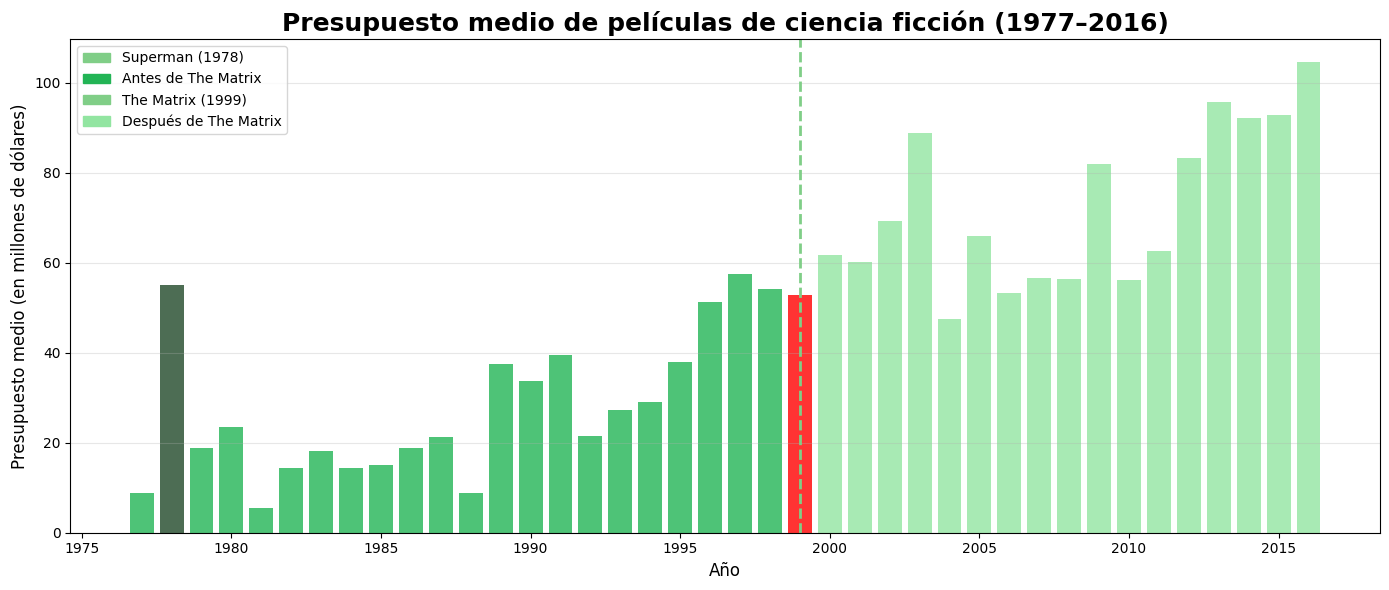

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

# Asigno colores según el año

colores = []
for year in presupuesto_anual['year']:
    if year == 1978:
        colores.append('#204829')
    elif year == 1999:
        colores.append('red')
    elif year < 1999:
        colores.append('#22b455')
    else:
        colores.append('#92e5a1')

ax.bar(presupuesto_anual['year'], presupuesto_anual['presupuesto_medio'] / 1_000_000, color=colores, alpha=0.8)

ax.axvline(1999, color='#80ce87', linestyle='--', linewidth=2)

# Leyenda manual
leyenda = [
    Patch(color='#80ce87',       label='Superman (1978)'),
    Patch(color='#22b455',  label='Antes de The Matrix'),
    Patch(color='#80ce87',        label='The Matrix (1999)'),
    Patch(color='#92e5a1', label='Después de The Matrix'),
]
ax.legend(handles=leyenda, fontsize=10)

ax.set_title('Presupuesto medio de películas de ciencia ficción (1977–2016)', fontsize=18, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Presupuesto medio (en millones de dólares)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### El gráfico muestra el presupuesto medio de las películas de ciencia ficción año a año desde 1977 hasta 2016. La línea roja marca el estreno de The Matrix en 1999. Destaca la barra dorada de 1978, correspondiente a Superman, que con 55 millones de dólares fue una superproducción excepcional para su época y un caso aislado que no marcó tendencia en el género. A partir de ahí, antes de 1999 los presupuestos rondaban entre 20 y 60 millones de dólares con bastante variación entre años. Tras el estreno de The Matrix la tendencia cambia claramente: los presupuestos suben de forma más consistente y se sitúan por encima de los 60 millones, llegando a superar los 100 millones en los últimos años del dataset. Y hay que tener en cuenta que no tenemos datos de los últimos años.

## En pocas palabras: después de The Matrix, gastar más dinero en ciencia ficción se convirtió en la norma. 

#### Nota: los presupuestos están en dólares corrientes de cada año, sin ajuste por inflación. Esto significa que parte del crecimiento que se observa se debe simplemente a que el dinero valía menos con el paso del tiempo. Con un ajuste por inflación, los presupuestos antiguos serían más altos de lo que aparecen, por lo que la diferencia real entre antes y después de 1999 sería menor, aunque la tendencia al alza probablemente seguiría siendo visible

# 🎬 Hipótesis 1 — Parte 2: Especialistas en VFX

#### Cargo el csv de créditos y miro los tres primeros registros y el info() para saber qué datos tengo entre manos

In [44]:
creditos = pd.read_csv('../datos/brutos/hipotesis_1/tmdb_5000_credits.csv')
creditos.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [45]:
creditos.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


#### Ya estoy observando que tanto el cast (actores y actrices) como el crew (todo el personal involucrado en las películas) no son simples strings, sino que estoy ante formato json.

In [46]:
print(creditos['crew'][0])

[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"}, 

#### Por tanto, del dataset solamente necesito las columnas movie_id y crew. Sin embargo, de la columna crew solamente necesito las personas que participaban en Visual Effects. Así que crearé una función para extraer a la gente que ha trabajado en ese campo. Después, cambiaré el nombre de la columna e incluiré en su interior una lista con las personas que me interesan para la segunda parte de la hipótesis.

In [47]:
def extraer_efectos(texto): # inicio la función
    lista = ast.literal_eval(texto) # convierto el string en diccionario
    return [persona['name'] for persona in lista if persona['department'] == 'Visual Effects'] # recorro el diccionario y me quedo solo con el campo name, pero si la persona está en el 
                                                                                               # departamento de efectos visuales

creditos['efectos'] = creditos['crew'].apply(extraer_efectos) # cambio el nombre de la columna crew a efectos y aplico la función para
                                                              # quedarme con lo que me interesa

creditos[['movie_id', 'efectos']].head(5) # muestro los cinco primeros registros del dataframe filtrado

,movie_id,efectos
0,19995,"[Jill Brooks, Richard Martin, Steven Quale, Jo..."
1,285,[]
2,206647,"[Laura Schultz, Sean McGrath, Mark Curtis, Ken..."
3,49026,"[May Leung, Mike Chambers, Pete Bebb, Claudia ..."
4,49529,"[Peter Chiang, Chris Corbould, Sue Rowe, Danie..."


#### Ya tengo el dataframe listo, pero, en realidad, lo único que necesito es la cantidad de personas que han participado en las películas en el apartados de efectos visuales. Para ello sustituyo la lista de personas por un conteo de los elementos de la lista. Es decir, cambio nombres por el total de personas que participaron.

In [48]:
creditos['total_personas_efectos'] = creditos['efectos'].apply(len) # añado una columna, que contendrá el número de personas de efectos
creditos[['movie_id', 'total_personas_efectos']].head(5) # muestro los primeros valores

,movie_id,total_personas_efectos
0,19995,26
1,285,0
2,206647,24
3,49026,7
4,49529,5


#### Para poder jugar con datos y gráficos, toca unir el dataset de películas de ciencia ficción con este que acabo de crear.

In [49]:
df_efectos = df_5000movies_scifi.merge(creditos[['movie_id', 'total_personas_efectos']], left_on='id', right_on='movie_id')
df_efectos.info()

<class 'pandas.DataFrame'>
RangeIndex: 475 entries, 0 to 474
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   budget                  475 non-null    int64         
 1   genres                  475 non-null    object        
 2   id                      475 non-null    int64         
 3   release_date            475 non-null    datetime64[us]
 4   revenue                 475 non-null    int64         
 5   title                   475 non-null    str           
 6   year                    475 non-null    int32         
 7   movie_id                475 non-null    int64         
 8   total_personas_efectos  475 non-null    int64         
dtypes: datetime64[us](1), int32(1), int64(5), object(1), str(1)
memory usage: 31.7+ KB


#### Me guardo el nuevo dataframe con el nombre peliculas_scifi_efectos

In [50]:
df_efectos.to_csv('../datos/procesados/hipotesis_1/peliculas_scifi_efectos.csv', index=False)

#### Ahora agruparé por año el dataframe de efectos y calcularé la media de personas en cada año que trabajaban en este campo en las películas de ciencia ficción

In [51]:
efectos_anual = df_efectos.groupby('year')['total_personas_efectos'].mean().reset_index() # agrupo por año y calculo la media de personas
efectos_anual.columns = ['year', 'media_trabajadores_efectos'] # el nuevo dataframe tendrá dos columnas: year y media_trabajadores_efectos
efectos_anual['media_trabajadores_efectos'] = efectos_anual['media_trabajadores_efectos'].round(0).astype(int) # convierto a int y redondeo sin decimales
efectos_anual = efectos_anual[efectos_anual['year'] >= 1977] # filtro desde el año 1977 (para comparar de la misma manera que en presupuestos)
efectos_anual.head(10) # previsualizo cómo ha quedado el dataframe

,year,media_trabajadores_efectos
13,1977,0
14,1978,0
15,1979,0
16,1980,1
17,1981,1
18,1982,0
19,1983,0
20,1984,0
21,1985,0
22,1986,2


#### Genero el gráfico en el que comparo la media de trabajadores de efectos visuales desde 1977 hasta 2016

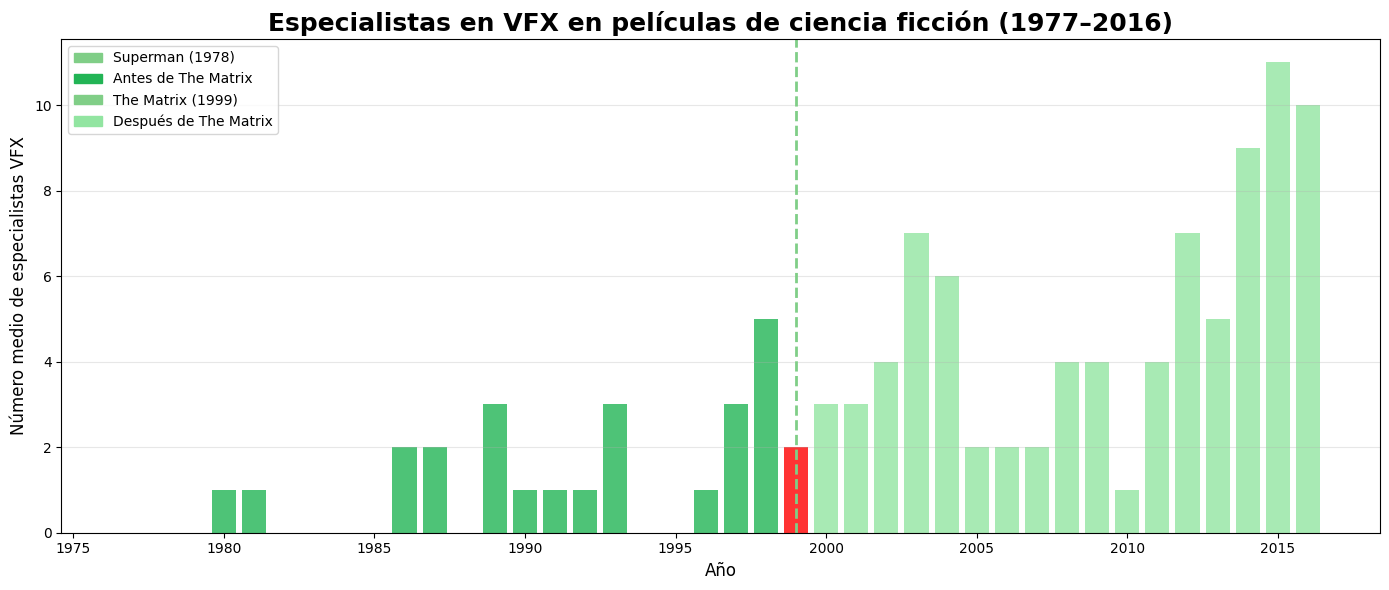

In [56]:
fig, ax = plt.subplots(figsize=(14, 6))

colores = []
for year in efectos_anual['year']:
    if year == 1978:
        colores.append('#204829')
    elif year == 1999:
        colores.append('red')
    elif year < 1999:
        colores.append('#22b455')
    else:
        colores.append('#92e5a1')

ax.bar(efectos_anual['year'], efectos_anual['media_trabajadores_efectos'], color=colores, alpha=0.8)

ax.axvline(1999, color='#80ce87', linestyle='--', linewidth=2)


leyenda = [
    Patch(color='#80ce87',       label='Superman (1978)'),
    Patch(color='#22b455',  label='Antes de The Matrix'),
    Patch(color='#80ce87',        label='The Matrix (1999)'),
    Patch(color='#92e5a1', label='Después de The Matrix'),
]
ax.legend(handles=leyenda, fontsize=10)

ax.set_title('Especialistas en VFX en películas de ciencia ficción (1977–2016)', fontsize=18, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Número medio de especialistas VFX', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### El gráfico muestra el número medio de especialistas en efectos visuales por película de ciencia ficción entre 1977 y 2016. La tendencia es más evidente que en el análisis de presupuestos: antes de 1999 las barras raramente superan los 3 o 4 profesionales de media, mientras que tras el estreno de The Matrix el número escala de forma progresiva y sostenida hasta superar los 10 en 2015 y 2016.

#### A diferencia del análisis de presupuestos, aquí no hay distorsión por inflación: estamos contando personas, no dinero, lo que hace la conclusión más directa. 

#### Dicho esto, el crecimiento no responde solo a un efecto Matrix. La mejora continua de las herramientas digitales (renderizado, motion capture, compositing) fue bajando el umbral técnico para producir efectos complejos, lo que permitió a más producciones incorporarlos y generó una demanda creciente de profesionales especializados. Matrix fue la película que convenció a la industria de apostar fuerte por los efectos visuales, pero fue la mejora de la tecnología lo que permitió que esa apuesta se mantuviera y creciera con los años. Y si tenemos en cuenta que muchas tareas que antes necesitaban equipos grandes hoy las resuelve el software, el crecimiento real en el uso de VFX fue probablemente aún mayor de lo que refleja este dato.